# 🍓 Taller rápido: pruebas de hipótesis con datos metagenómicos

## Versión resumida, de una hora

**Python · Google Colab · 4 episodios · 57 min**

¿El microbioma de la raíz de una planta de fresa saludable es distinto del de una planta marchita? Para responder no basta con comparar dos promedios: hay que decidir si la diferencia es mayor que la que produciría el azar. En una hora verás cómo se toma esa decisión y por qué dos pruebas pueden dar respuestas distintas sobre los mismos datos.

Cada prueba se aplica a **dos casos**: unos datos **simulados**, en los que conocemos la verdad y los supuestos se cumplen, y unos datos **reales**, en los que no.

## ¿Para quién es este taller?

Para quien quiera **entender las pruebas estadísticas que se usan para comparar muestras de datos metagenómicos** y tenga poco tiempo. No es un taller de bioinformática ni de programación: el código ya está escrito y comentado paso a paso, y lo que se trabaja es qué se hace en cada prueba y por qué.

## Conocimientos previos

Este taller empieza donde terminan estas lecciones de [The Carpentries](https://carpentries.org). No es obligatorio haberlas tomado, pero son el punto de partida recomendado:

- **Cómo se obtienen los datos:** [Data Processing and Visualization for Metagenomics](https://carpentries-lab.github.io/metagenomics-analysis/), de Carpentries Lab. Va de las lecturas a la tabla de conteos y a las gráficas de diversidad.
- **El código de Python:** [Plotting and Programming in Python](https://swcarpentry.github.io/python-novice-gapminder/), de Software Carpentry.
- **Las tablas de pandas:** [Data Analysis and Visualization in Python for Ecologists](https://datacarpentry.github.io/python-ecology-lesson/), de Data Carpentry. En español: [Análisis y visualización de datos usando Python](https://datacarpentry.github.io/python-ecology-lesson-es/).

## Objetivos generales

Al terminar el taller podrás:

1. **Explicar** qué es un valor p y construir uno a mano, barajando etiquetas.
2. **Comprobar** los supuestos de una prueba antes de aplicarla.
3. **Elegir** entre la t de Student, la t de Welch y Mann-Whitney para comparar un índice entre dos grupos.
4. **Interpretar** un PERMANOVA junto con PERMDISP y una ordenación.

## Índice

| Inicio | Episodio | Pregunta que responde | Explicación | Ejercicio |
|---|---|---|---|---|
| 0:00 | **1. Dos casos y una pregunta** | ¿Qué datos vamos a comparar y por qué hay dos casos? | 10 min | — |
| 0:10 | **2. ¿Diferencia real o azar? El valor p** | ¿Cómo sé si la diferencia entre dos grupos es mayor que la que produciría el azar? | 10 min | 4 min |
| 0:24 | **3. Elegir la prueba: supuestos, Welch y Mann-Whitney** | ¿Qué supone cada prueba y qué pasa cuando los datos no lo cumplen? | 10 min | 4 min |
| 0:38 | **4. Comparar comunidades completas: PERMANOVA y PERMDISP** | ¿Cómo comparo comunidades enteras y no un solo número por muestra? | 15 min | 4 min |
| 0:57 | *Fin* | | | |

Son 45 min de explicación y 12 min de ejercicios. Hay **3 ejercicios** cortos, con la solución escondida: intenta resolver cada uno antes de abrirla.

Cada episodio tiene la misma organización: **preguntas y objetivos**, **explicación paso a paso** (qué se hace, por qué, y el código comentado), una pregunta **para pensar** antes de ver el resultado real, un **ejercicio** y los **puntos clave**.

## Cómo usar este cuaderno

1. En Google Colab: **Archivo → Subir notebook**, o ábrelo desde GitHub con **Archivo → Abrir notebook → GitHub**.
2. Ejecuta las celdas en orden con **Shift + Enter**. Los datos reales se descargan solos desde GitHub; no hay que subir nada.
3. Solo se usan `numpy`, `pandas`, `scipy` y `matplotlib`, que ya vienen instalados en Colab.

Los datos reales fueron facilitados por la empresa [Solena Ag](https://www.solena.ag) (2023) y están publicados en
[GitHub](https://github.com/CamilaSilva1995/Tesis_Maestria/tree/main/Taller_Practico/datos).

---
## Episodio 1. Dos casos y una pregunta

⏱️ **Explicación: 10 min**

> **❓ Preguntas**
> - ¿Qué datos vamos a comparar y por qué hay dos casos?
>
> **🎯 Objetivos**
> - Cargar los datos reales y unir sus tablas por el identificador de la muestra.
> - Generar un caso simulado en el que conocemos la verdad.

La pregunta de todo el taller es una sola: **¿las plantas saludables y las no saludables difieren, o la diferencia que vemos es azar?** La vamos a responder en dos casos.

**Caso real.** 53 metagenomas de la rizósfera de la fresa: 35 de plantas saludables y 18 de no saludables. Llegan en tres tablas: los metadatos de cada muestra, sus índices de diversidad alfa (entre ellos el de Shannon, que resume en un número cuántos taxones hay y qué tan repartidas están las lecturas) y los conteos de lecturas por género. Cómo se obtienen esas tablas a partir de las lecturas está explicado en la lección [*Data Processing and Visualization for Metagenomics*](https://carpentries-lab.github.io/metagenomics-analysis/) de The Carpentries; aquí empezamos con las tablas ya hechas.

La primera celda prepara las herramientas: no hace falta leerla en detalle.

In [1]:
# Para que las figuras se dibujen dentro del cuaderno, debajo de la celda que las crea
%matplotlib inline
import numpy as np                                      # arreglos numéricos y números aleatorios
import pandas as pd                                     # tablas de datos (DataFrame)
import matplotlib.pyplot as plt                         # figuras
from scipy import stats                                 # pruebas estadísticas (t, Mann-Whitney, etc.)
from scipy.spatial.distance import pdist, squareform    # distancias entre muestras (Episodio 4)

# Carpeta del repositorio de GitHub donde están los archivos CSV de la clase
URL = "https://raw.githubusercontent.com/CamilaSilva1995/Tesis_Maestria/main/Taller_Practico/datos/"

def cargar(nombre):
    "Lee un CSV desde GitHub; si no hay internet, desde la carpeta local datos/."
    try:
        return pd.read_csv(URL + nombre)        # primer intento: descargarlo de GitHub
    except Exception:
        return pd.read_csv("datos/" + nombre)   # si falla, leer la copia local

def formato_p(p):
    "Escribe un valor p con cuatro decimales; los muy pequeños, en notación científica."
    return f"{p:.4f}" if p >= 1e-4 else f"{p:.1e}"

def grafica_nula(nulos, observado, etiqueta_x, titulo, bilateral=True):
    "Histograma de un estadístico con las etiquetas barajadas (H0) y, en rojo, el valor observado."
    fig, ax = plt.subplots()
    ax.hist(nulos, bins=50, color="lightgray", edgecolor="white")
    ax.axvline(observado, color="red", lw=2, label=f"observado = {observado:.3f}")
    if bilateral:                                        # en una prueba bilateral cuenta también el lado contrario
        ax.axvline(-observado, color="red", lw=2, ls="--")
    ax.set_xlabel(etiqueta_x); ax.set_ylabel("Número de barajadas")
    ax.set_title(titulo); ax.legend(); plt.show()

# Tamaño de las figuras y de la letra para todo el cuaderno
plt.rcParams.update({"figure.figsize": (8, 4.5), "font.size": 11})
# Un color fijo por grupo, para que todas las figuras se lean igual
COLORES = {"Saludable": "#F8766D", "No saludable": "#00BFC4"}
GRUPOS = ["Saludable", "No saludable"]                  # el orden de los grupos en las figuras
# Versiones instaladas: conviene anotarlas para poder reproducir los resultados
print("Listo. numpy", np.__version__, "| pandas", pd.__version__, "| scipy", __import__("scipy").__version__)

Listo. numpy 2.5.2 | pandas 3.0.5 | scipy 1.18.1


In [2]:
# Las tres tablas reales. set_index("muestra") pone el identificador de la muestra como índice:
# así las tablas se unen por identificador y no por posición
meta = cargar("metadatos.csv").set_index("muestra")          # grupo y lecturas clasificadas de cada muestra
alfa = cargar("diversidad_alfa.csv").set_index("muestra")    # índices de diversidad alfa (Shannon, Chao1...)
conteos = cargar("conteos_por_genero.csv")                   # una fila por género y una columna por muestra

# Filtro de calidad: se descartan cinco muestras con menos de 25 millones de lecturas
excluir = ["MP2079", "MP2080", "MP2088", "MP2109", "MP2137"]
datos = meta.join(alfa, how="inner").drop(index=excluir)     # une por identificador y quita esas cinco
muestras = list(datos.index)                                 # las 53 muestras reales del taller

# la tabla de géneros, con las mismas muestras y en el MISMO orden que 'datos'
generos = conteos.set_index(["reino", "filo", "genero"])[muestras]
# assert detiene la ejecución con un error si la condición no se cumple
assert list(generos.columns) == muestras                     # comprobación: las tablas quedaron emparejadas

print(datos.grupo.value_counts())                            # cuántas muestras hay en cada grupo
display(datos[["grupo", "lecturas_clasificadas", "shannon", "chao1"]].head())

grupo
Saludable       35
No saludable    18
Name: count, dtype: int64


,grupo,lecturas_clasificadas,shannon,chao1
muestra,,,,
MD2055,No saludable,9782432,7.466004,8720.286
MD2056,No saludable,12468526,7.485615,8789.198
MD2065,No saludable,11297600,7.318039,8744.387
MD2066,No saludable,15580959,7.506399,8784.103
MD2075,No saludable,12310781,7.437571,8811.039


**Caso ideal (simulado).** Los datos reales rara vez se portan como piden los libros. Para ver cómo funciona cada prueba **cuando todo se cumple**, fabricamos un segundo estudio en el que nosotros decidimos la verdad:

- **Diseño balanceado:** 30 plantas saludables y 30 no saludables.
- **Diversidad:** el índice de Shannon es **normal**, con la **misma desviación estándar** (0.05) en los dos grupos y medias distintas: 7.48 y 7.42, las que se observan en los datos reales.
- **Composición:** 40 géneros; en las no saludables uno de ellos, `G05`, es cuatro veces más abundante.

In [3]:
rng_sim = np.random.default_rng(2026)          # generador aleatorio con semilla: todos obtenemos los mismos datos
n_sim = 30                                     # muestras por grupo: diseño balanceado

# 1. Índice de Shannon: medias distintas, misma desviación estándar, distribución normal
media_sal, media_no, desviacion = 7.48, 7.42, 0.05
# Identificadores: S01...S30 para las saludables y N01...N30 para las no saludables
ids = [f"S{i:02d}" for i in range(1, n_sim + 1)] + [f"N{i:02d}" for i in range(1, n_sim + 1)]
datos_sim = pd.DataFrame({
    "grupo": ["Saludable"] * n_sim + ["No saludable"] * n_sim,
    # rng_sim.normal(media, desviación, cuántos): valores al azar de una distribución normal
    "shannon": np.concatenate([rng_sim.normal(media_sal, desviacion, n_sim),
                               rng_sim.normal(media_no, desviacion, n_sim)]),
}, index=pd.Index(ids, name="muestra"))

# 2. Tabla de géneros: composición promedio de cada grupo y variación al azar de muestra a muestra
n_generos, lecturas_sim, variabilidad = 40, 100_000, 0.25
nombres = [f"G{i:02d}" for i in range(1, n_generos + 1)]        # G01, G02, ..., G40
patogeno = "G05"                                                 # el género que hacemos más abundante
comp_sal = pd.Series(1 / np.arange(1, n_generos + 1), index=nombres)
comp_sal = comp_sal / comp_sal.sum()                             # saludables: pocos géneros abundantes, muchos escasos
comp_no = comp_sal.copy()
comp_no[patogeno] = 4 * comp_no[patogeno]                        # no saludables: G05 cuatro veces más abundante
comp_no = comp_no / comp_no.sum()                                # las proporciones vuelven a sumar 1

def simular_muestras(composicion, n_muestras):
    "Simula n_muestras columnas de conteos alrededor de una composición promedio."
    columnas = []
    for _ in range(n_muestras):
        # cada género se desvía al azar de su promedio (la misma variabilidad en los dos grupos)
        p = composicion.to_numpy() * np.exp(rng_sim.normal(0, variabilidad, len(composicion)))
        p = p / p.sum()
        columnas.append(rng_sim.multinomial(lecturas_sim, p))    # se "secuencian" 100 000 lecturas
    return np.array(columnas).T                                  # filas = géneros, columnas = muestras

generos_sim = pd.DataFrame(np.hstack([simular_muestras(comp_sal, n_sim), simular_muestras(comp_no, n_sim)]),
                           index=pd.Index(nombres, name="genero"), columns=datos_sim.index)
assert list(generos_sim.columns) == list(datos_sim.index)        # emparejadas por identificador

# Lo que salió en estas 60 muestras: se parece a la verdad, pero no es idéntico
display(datos_sim.groupby("grupo").shannon.agg(["count", "mean", "std"]).round(3))

,count,mean,std
grupo,,,
No saludable,30,7.443,0.055
Saludable,30,7.480,0.040


La verdad es una diferencia de 0.06 entre las medias; en estas 60 muestras se observa una de 0.037. Esa distancia entre la verdad y lo observado es la **variación de muestreo**, y es lo que una prueba de hipótesis tiene que tener en cuenta.

> **🔑 Puntos clave**
> - Las tablas se unen por el identificador de la muestra, nunca por posición, y se comprueba con `assert`.
> - En los datos simulados conocemos la verdad porque la elegimos: sirven para ver cómo se comporta una prueba cuando sus supuestos se cumplen.
> - Lo observado en una muestra nunca coincide exactamente con la verdad: eso es la variación de muestreo.

---
## Episodio 2. ¿Diferencia real o azar? El valor p

⏱️ **Explicación: 10 min · Ejercicio: 4 min**

> **❓ Preguntas**
> - ¿Cómo sé si la diferencia entre dos grupos es mayor que la que produciría el azar?
>
> **🎯 Objetivos**
> - Formular la hipótesis nula de una comparación entre dos grupos.
> - Construir un valor p a mano, barajando las etiquetas de grupo.
> - Interpretar un valor p sin sobreinterpretarlo.

**Qué hacemos.** Comparamos el índice de Shannon promedio de los dos grupos y preguntamos si la diferencia observada es mayor que la que daría el azar.

**Por qué así.** La **hipótesis nula** $H_0$ dice que el grupo no importa: la etiqueta «saludable» o «no saludable» es intercambiable. Si fuera cierta, podríamos **barajar las etiquetas** y la diferencia de medias cambiaría solo por azar. Barajando 5 000 veces obtenemos lo que el azar produce bajo $H_0$. El **valor p** es la fracción de barajadas con una diferencia tan grande, o más, que la observada.

Empezamos con los datos simulados, donde sabemos que la diferencia existe.

Diferencia observada = 0.037. De 5 000 barajadas, 29 la igualan o superan: p = 0.0058


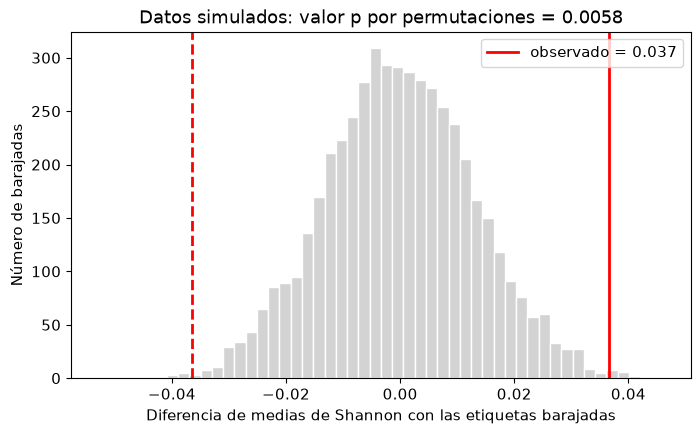

In [4]:
# Shannon de cada grupo como arreglo de numpy: x_sim = saludables (30), y_sim = no saludables (30)
x_sim = datos_sim.loc[datos_sim.grupo == "Saludable", "shannon"].to_numpy()
y_sim = datos_sim.loc[datos_sim.grupo == "No saludable", "shannon"].to_numpy()
dif_sim = x_sim.mean() - y_sim.mean()                    # la diferencia que vemos en estas muestras

rng = np.random.default_rng(2026)                        # generador aleatorio con semilla: el resultado se repite
todos = np.concatenate([x_sim, y_sim])                   # los 60 valores juntos, sin etiqueta de grupo
barajadas_sim = []                                       # aquí se guarda la diferencia de cada barajada
for _ in range(5000):
    rng.shuffle(todos)                                   # barajar etiquetas
    # los primeros 30 valores hacen de "saludables" y los 30 restantes, de "no saludables"
    barajadas_sim.append(todos[:len(x_sim)].mean() - todos[len(x_sim):].mean())
barajadas_sim = np.array(barajadas_sim)                  # de lista a arreglo, para operar con todas a la vez

# valor p: fracción de barajadas con una diferencia al menos tan grande como la observada
extremas = np.abs(barajadas_sim) >= abs(dif_sim)         # bilateral: cuenta en los dos sentidos
p_perm_sim = np.mean(extremas)
print(f"Diferencia observada = {dif_sim:.3f}. De 5 000 barajadas, {extremas.sum()} la igualan o superan: p = {p_perm_sim:.4f}")
grafica_nula(barajadas_sim, dif_sim, "Diferencia de medias de Shannon con las etiquetas barajadas",
             f"Datos simulados: valor p por permutaciones = {p_perm_sim:.4f}")

**Lee la figura.** El histograma gris es lo que produce el azar cuando el grupo no importa; las líneas rojas, la diferencia observada. Muy pocas barajadas llegan tan lejos: $p \approx 0.006$. Rechazamos $H_0$ y, como conocemos la verdad, sabemos que la prueba acertó.

> 💬 **Para pensar (1 min).** En los datos reales la diferencia observada es 0.061, **mayor** que la de los simulados (0.037). ¿Esperas un valor p más pequeño?

Diferencia observada = 0.061: p = 0.0408

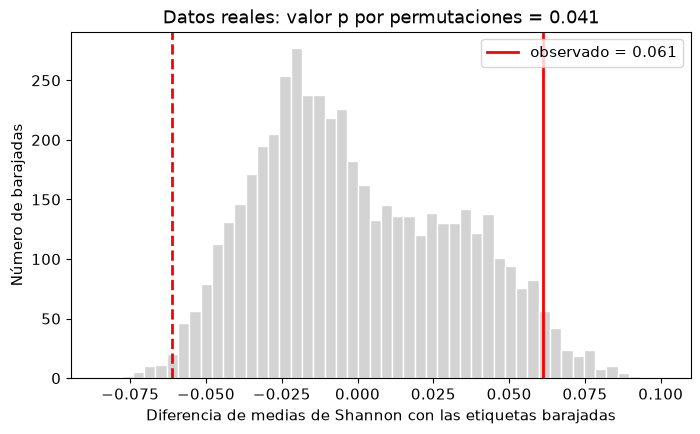

In [5]:
def prueba_permutacion(x, y, n_perm=5000, semilla=2026):
    "Los pasos de la celda anterior en una función: devuelve la diferencia observada, las barajadas y el valor p."
    rng = np.random.default_rng(semilla)
    observada = x.mean() - y.mean()
    todos = np.concatenate([x, y])                       # todos los valores, sin etiqueta de grupo
    barajadas = []
    for _ in range(n_perm):
        rng.shuffle(todos)                               # barajar etiquetas
        barajadas.append(todos[:len(x)].mean() - todos[len(x):].mean())
    barajadas = np.array(barajadas)
    return observada, barajadas, np.mean(np.abs(barajadas) >= abs(observada))

# Shannon de cada grupo en los datos reales: x = saludables (35), y = no saludables (18)
x = datos.loc[datos.grupo == "Saludable", "shannon"].to_numpy()
y = datos.loc[datos.grupo == "No saludable", "shannon"].to_numpy()
dif_real, barajadas_real, p_perm_real = prueba_permutacion(x, y)
print(f"Diferencia observada = {dif_real:.3f}: p = {p_perm_real:.4f}")
grafica_nula(barajadas_real, dif_real, "Diferencia de medias de Shannon con las etiquetas barajadas",
             f"Datos reales: valor p por permutaciones = {p_perm_real:.3f}")

En los datos reales $p \approx 0.04$: significativo, pero menos contundente que en los simulados, aunque la diferencia es mayor. **El valor p no depende solo de la diferencia: depende también de cuánto varían los datos y de cuántas muestras hay.** El histograma asimétrico delata una planta no saludable con un Shannon muy bajo. Guarda ese 0.04: en el siguiente episodio otras pruebas darán otra cosa.

Dos ideas para fijar: un valor p **no** es la probabilidad de que $H_0$ sea cierta, y un p mayor que 0.05 **no demuestra** que los grupos sean iguales.

### ✏️ Ejercicio 1: Interpretar el valor p

⏱️ *4 min*

1. Un compañero dice: «p = 0.15 significa que hay 15 % de probabilidad de que los grupos sean iguales». ¿Qué está mal?
2. Ejecuta `prueba_permutacion(x_sim[:5], y_sim[:5])[2]`, que repite la prueba con solo cinco muestras simuladas por grupo. La diferencia verdadera no cambió. ¿Qué pasa con el valor p y por qué?

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

1. Confunde $P(\text{datos} \mid H_0)$ con $P(H_0 \mid \text{datos})$. El valor p se calcula suponiendo que $H_0$ es cierta; no dice nada sobre la probabilidad de $H_0$.
2. El valor p sube a cerca de 0.28 y deja de ser significativo. Con pocas muestras el promedio de cada grupo varía mucho de una barajada a otra y la diferencia observada ya no queda en la cola. No detectar una diferencia no demuestra que no exista.

```python
# [2] es el tercer resultado de la función: el valor p
print("Con 5 muestras por grupo: p =", round(prueba_permutacion(x_sim[:5], y_sim[:5])[2], 3))
print("Con 30 muestras por grupo: p =", round(p_perm_sim, 4))
```

</details>

> **🔑 Puntos clave**
> - La hipótesis nula dice que el grupo no importa: las etiquetas son intercambiables.
> - El valor p es la fracción de resultados que, si la hipótesis nula fuera cierta, serían al menos tan extremos como el observado.
> - El valor p depende de la diferencia, de la variabilidad y del tamaño de muestra.

---
## Episodio 3. Elegir la prueba: supuestos, Welch y Mann-Whitney

⏱️ **Explicación: 10 min · Ejercicio: 4 min**

> **❓ Preguntas**
> - ¿Qué supone cada prueba y qué pasa cuando los datos no lo cumplen?
>
> **🎯 Objetivos**
> - Comprobar la normalidad y la igualdad de varianzas antes de aplicar una prueba.
> - Aplicar la t de Student, la t de Welch y Mann-Whitney a los mismos datos.
> - Decidir cuál de los resultados es válido.

**Qué hacemos.** Barajar etiquetas es una forma de obtener el valor p. Las pruebas clásicas lo obtienen con una fórmula, y cada fórmula vale solo si se cumplen sus **supuestos**:

| Prueba | Qué compara | Qué supone |
|---|---|---|
| **t de Student** | Las medias | Grupos normales y con la **misma varianza** |
| **t de Welch** | Las medias | Grupos normales; **no** supone varianzas iguales |
| **Mann-Whitney** | Los rangos (el orden de los valores) | **No** supone normalidad; resiste los valores atípicos |

**Por qué así.** Los supuestos se comprueban antes de mirar el valor p: la normalidad con **Shapiro-Wilk** y la igualdad de varianzas con la **prueba F**. En las dos, un p pequeño significa que el supuesto **no** se cumple. Y antes que cualquier prueba, se miran los datos.

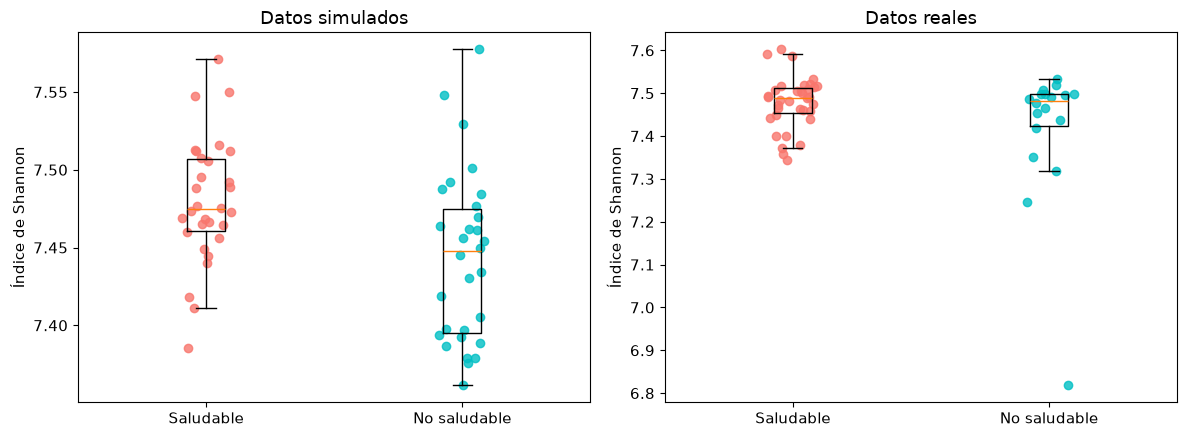

In [6]:
# Un panel por caso: diagrama de caja de cada grupo con el punto de cada muestra encima
fig, paneles = plt.subplots(1, 2, figsize=(12, 4.5))
rng = np.random.default_rng(1)                           # solo para separar los puntos horizontalmente
for ax, (caso, a, b) in zip(paneles, [("Datos simulados", x_sim, y_sim), ("Datos reales", x, y)]):
    # showfliers=False: los atípicos no se marcan aparte, porque ya se dibujan todos los puntos
    ax.boxplot([a, b], showfliers=False)
    ax.set_xticks([1, 2], GRUPOS)                        # nombre de cada caja (posiciones 1 y 2)
    # i = 1, 2 es la posición de cada caja; el desplazamiento al azar evita que los puntos se tapen
    for i, (v, g) in enumerate(zip([a, b], GRUPOS), 1):
        ax.scatter(i + rng.uniform(-0.1, 0.1, len(v)), v, color=COLORES[g], alpha=0.8)
    ax.set_ylabel("Índice de Shannon"); ax.set_title(caso)
fig.tight_layout()                                       # acomoda los paneles para que los rótulos no se monten
plt.show()

> 💬 **Para pensar (1 min).** Mira las dos figuras. ¿En cuál de los casos crees que las tres pruebas van a coincidir? ¿Qué supuesto parece fallar en el otro? (Ojo: cada panel tiene su propia escala.)

In [7]:
def comparar_grupos(x, y):
    "Supuestos y tres pruebas para dos grupos: devuelve una columna de resultados."
    F = x.var(ddof=1) / y.var(ddof=1)                    # cociente de varianzas muestrales (ddof=1 divide entre n - 1)
    cola = stats.f.cdf(F, len(x) - 1, len(y) - 1)        # probabilidad a la izquierda de F
    return {
        "Muestras (saludable, no saludable)":            f"{len(x)}, {len(y)}",
        "Media (saludable, no saludable)":               f"{x.mean():.3f}, {y.mean():.3f}",
        "Desv. estándar (saludable, no saludable)":      f"{x.std(ddof=1):.3f}, {y.std(ddof=1):.3f}",
        # supuestos: un p pequeño indica que el supuesto NO se cumple
        "Supuesto de normalidad, saludable: p":          formato_p(stats.shapiro(x).pvalue),
        "Supuesto de normalidad, no saludable: p":       formato_p(stats.shapiro(y).pvalue),
        "Supuesto de varianzas iguales (prueba F): p":   formato_p(2 * min(cola, 1 - cola)),   # bilateral
        # pruebas: un p pequeño indica que los grupos difieren
        "t de Student: p":                               formato_p(stats.ttest_ind(x, y, equal_var=True).pvalue),
        "t de Welch: p":                                 formato_p(stats.ttest_ind(x, y, equal_var=False).pvalue),
        "Mann-Whitney: p":                               formato_p(stats.mannwhitneyu(x, y, alternative="two-sided", method="exact").pvalue),
    }

# Una columna por caso: las filas quedan alineadas porque las dos columnas tienen los mismos nombres
display(pd.DataFrame({"Datos simulados": comparar_grupos(x_sim, y_sim), "Datos reales": comparar_grupos(x, y)}))

,Datos simulados,Datos reales
"Muestras (saludable, no saludable)","30, 30","35, 18"
"Media (saludable, no saludable)","7.480, 7.443","7.478, 7.417"
"Desv. estándar (saludable, no saludable)","0.040, 0.055","0.061, 0.168"
"Supuesto de normalidad, saludable: p",0.8372,0.1300
"Supuesto de normalidad, no saludable: p",0.1853,9.0e-06
Supuesto de varianzas iguales (prueba F): p,0.1128,6.8e-07
t de Student: p,0.0046,0.0581
t de Welch: p,0.0047,0.1501
Mann-Whitney: p,0.0032,0.2586


**Caso ideal.** Los supuestos se cumplen (ningún p de supuesto es pequeño) y las tres pruebas coinciden con la permutación: $p$ entre 0.003 y 0.006. **Cuando los supuestos se cumplen, las pruebas cuentan la misma historia.**

**Caso real.** El grupo no saludable no es normal y su varianza es más de siete veces mayor. Las pruebas ya no coinciden: Student da 0.058, Welch 0.150 y Mann-Whitney 0.259; la permutación había dado 0.04. Valen las que respetan los datos, Welch y Mann-Whitney: **no hay evidencia de que la diversidad promedio difiera.** La respuesta correcta no es la de la prueba con el p más pequeño, sino la de la prueba cuyos supuestos se cumplen.

Lo que sí es claro en los datos reales es otra cosa: las plantas no saludables **son más variables entre sí**. Eso es un resultado, no solo un problema.

### ✏️ Ejercicio 2: La misma decisión con otro índice

⏱️ *4 min*

Aplica `comparar_grupos` al estimador de riqueza **Chao1** de los datos reales (columna `chao1`). Según los supuestos, ¿qué prueba corresponde? ¿Cuál es la conclusión?

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

La prueba F da $p \approx 0.057$, justo por encima de 0.05, y el grupo no saludable queda en el límite de la normalidad ($p \approx 0.04$). Con supuestos en duda lo prudente es no fiarse de una sola prueba: Student da 0.35, Welch 0.41 y Mann-Whitney 0.58. Las tres coinciden: no hay evidencia de que la riqueza estimada con Chao1 difiera entre los grupos.

```python
# Chao1 de cada grupo
xc = datos.loc[datos.grupo == "Saludable", "chao1"].to_numpy()
yc = datos.loc[datos.grupo == "No saludable", "chao1"].to_numpy()
display(pd.DataFrame({"Chao1, datos reales": comparar_grupos(xc, yc)}))
```

</details>

> **🔑 Puntos clave**
> - Antes de cualquier prueba se miran los datos y se comprueban los supuestos.
> - La t de Student supone varianzas iguales; la de Welch no. Mann-Whitney trabaja con rangos y no supone normalidad.
> - Cuando los supuestos se cumplen, las pruebas coinciden. Cuando no coinciden, vale la que respeta los datos, no la que da el valor p más pequeño.

---
## Episodio 4. Comparar comunidades completas: PERMANOVA y PERMDISP

⏱️ **Explicación: 15 min · Ejercicio: 4 min**

> **❓ Preguntas**
> - ¿Cómo comparo comunidades enteras y no un solo número por muestra?
>
> **🎯 Objetivos**
> - Calcular la disimilitud de Bray-Curtis entre muestras.
> - Interpretar el pseudo-F, el R² y el valor p de un PERMANOVA.
> - Comprobar con PERMDISP y con una ordenación si los grupos difieren en dispersión.

Una muestra no es un número: es un vector de abundancias, 40 géneros en los datos simulados y 1 795 en los reales.

**Qué hacemos**, en tres pasos:

1. **Una distancia entre muestras.** La disimilitud de **Bray-Curtis** vale 0 si dos muestras tienen la misma composición y 1 si no comparten ningún taxón.
2. **Un estadístico.** El **PERMANOVA** reparte la variación en dos partes, la que hay **entre** grupos y la que hay **dentro** de ellos, y forma un cociente, el pseudo-F. El $R^2$ es la fracción de la variación que explica el grupo.
3. **Un valor p por permutaciones**, como en el Episodio 2: se barajan las etiquetas y se cuenta cuántas veces el pseudo-F supera al observado.

**Por qué así.** No hay una «prueba t para vectores» que funcione con cientos de taxones y pocas muestras. Con distancias y permutaciones no hay que suponer una distribución.

In [8]:
# Paso 1: abundancias relativas y matriz de distancias de cada caso
# cada columna (muestra) se divide entre su total; .T deja las muestras en filas
rel_sim = (generos_sim / generos_sim.sum(axis=0)).T      # 60 muestras x 40 géneros, cada fila suma 1
rel = (generos / generos.sum(axis=0)).T                  # 53 muestras x 1 795 géneros
# pdist calcula la distancia de cada par de muestras; squareform las acomoda en una matriz cuadrada
D_sim = squareform(pdist(rel_sim.to_numpy(), metric="braycurtis"))
D = squareform(pdist(rel.to_numpy(), metric="braycurtis"))

# Grupo de cada muestra, en el mismo orden que las filas de cada matriz
etiquetas_sim = datos_sim.grupo.to_numpy()
etiquetas = datos.grupo.to_numpy()
print("Matrices de distancias:", D_sim.shape, "simulados |", D.shape, "reales")

Matrices de distancias: (60, 60) simulados | (53, 53) reales


In [9]:
def pseudo_F(D, etiquetas):
    "Pseudo-F y R2 del PERMANOVA a partir de la matriz de distancias y el grupo de cada muestra."
    n = len(etiquetas)
    grupos = np.unique(etiquetas)
    # variación total: distancias al cuadrado de todos los pares, entre n (cada par se cuenta dos veces: por eso el 2)
    SS_total = (D ** 2).sum() / (2 * n)
    # variación dentro de los grupos: lo mismo, solo con los pares de un mismo grupo
    SS_dentro = sum((D[np.ix_(etiquetas == g, etiquetas == g)] ** 2).sum() / (2 * (etiquetas == g).sum())
                    for g in grupos)
    SS_entre = SS_total - SS_dentro     # lo que queda es la variación entre grupos
    # cada suma de cuadrados se divide entre sus grados de libertad, como en el ANOVA
    F = (SS_entre / (len(grupos) - 1)) / (SS_dentro / (n - len(grupos)))
    return F, SS_entre / SS_total       # pseudo-F y R2 (fracción de la variación que explica el grupo)

def permanova(D, etiquetas, n_perm=999, semilla=2026):
    "PERMANOVA: devuelve el pseudo-F observado, el R2 y el valor p por permutaciones."
    rng = np.random.default_rng(semilla)
    F_obs, R2 = pseudo_F(D, etiquetas)                      # estadístico con las etiquetas reales
    # se barajan las etiquetas n_perm veces y se guarda el pseudo-F de cada barajada
    F_perm = np.array([pseudo_F(D, rng.permutation(etiquetas))[0] for _ in range(n_perm)])
    p = (np.sum(F_perm >= F_obs) + 1) / (n_perm + 1)        # +1: la observación cuenta como una permutación
    return F_obs, R2, p

def pcoa(D):
    "Coordenadas principales a partir de una matriz de distancias; las primeras columnas recogen más variación."
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n        # matriz de centrado
    B = J @ (-0.5 * D ** 2) @ J                # doble centrado de -1/2 por las distancias al cuadrado
    val, vec = np.linalg.eigh(B)               # valores y vectores propios (B es simétrica), de menor a mayor
    val, vec = val[::-1], vec[:, ::-1]         # se invierte el orden: primero los ejes más importantes
    keep = val > 1e-10                         # se descartan los valores propios nulos o negativos
    return vec[:, keep] * np.sqrt(val[keep])   # coordenadas: vector propio por la raíz de su valor propio

def permdisp(D, etiquetas, n_perm=999, semilla=2026):
    "PERMDISP: compara entre grupos la distancia de cada muestra al centroide de su grupo."
    coords = pcoa(D)
    dist_centro = np.empty(len(etiquetas))     # aquí va la distancia de cada muestra a su centroide
    for g in np.unique(etiquetas):
        m = etiquetas == g                     # máscara: True en las muestras del grupo g
        centro = coords[m].mean(axis=0)        # centroide: promedio de las coordenadas del grupo
        dist_centro[m] = np.sqrt(((coords[m] - centro) ** 2).sum(axis=1))
    grupos = [dist_centro[etiquetas == g] for g in np.unique(etiquetas)]
    F_obs = stats.f_oneway(*grupos).statistic  # ANOVA de una vía sobre esas distancias
    rng = np.random.default_rng(semilla)
    # valor p por permutaciones: se barajan las etiquetas y se repite el ANOVA
    F_perm = [stats.f_oneway(*[dist_centro[rng.permutation(etiquetas) == g] for g in np.unique(etiquetas)]).statistic
              for _ in range(n_perm)]
    return dist_centro, (np.sum(np.array(F_perm) >= F_obs) + 1) / (n_perm + 1)

> 💬 **Para pensar (1 min).** En los datos simulados cambiamos un género de 40. En los reales no sabemos si algo cambió. ¿Qué $R^2$ esperas en cada caso: grande o pequeño?

In [10]:
for caso, matriz, grupo in [("Datos simulados", D_sim, etiquetas_sim), ("Datos reales", D, etiquetas)]:
    F_caso, R2_caso, p_caso = permanova(matriz, grupo)
    dist_centro, p_disp = permdisp(matriz, grupo)
    print(caso)
    print(f"   PERMANOVA: pseudo-F = {F_caso:.2f}, R2 = {R2_caso:.3f} (el grupo explica el {100 * R2_caso:.1f} % de la variación), p = {p_caso:.3f}")
    # distancia media de las muestras de cada grupo a su centroide: cuánto se dispersa el grupo
    dispersion = ", ".join(f"{g} {dist_centro[grupo == g].mean():.3f}" for g in GRUPOS)
    print(f"   PERMDISP:  distancia media al centroide: {dispersion}; p = {p_disp:.3f}")

Datos simulados
   PERMANOVA: pseudo-F = 22.86, R2 = 0.283 (el grupo explica el 28.3 % de la variación), p = 0.001
   PERMDISP:  distancia media al centroide: Saludable 0.104, No saludable 0.105; p = 0.654


Datos reales
   PERMANOVA: pseudo-F = 1.14, R2 = 0.022 (el grupo explica el 2.2 % de la variación), p = 0.282
   PERMDISP:  distancia media al centroide: Saludable 0.069, No saludable 0.092; p = 0.005


El PERMANOVA tiene una trampa: también reacciona cuando un grupo es **más disperso** que el otro, aunque sus centros coincidan. Por eso se acompaña con **PERMDISP**, que compara la distancia de cada muestra al centro de su grupo, y con una **ordenación**, que dibuja las muestras de modo que las distancias en el plano se parezcan a las de Bray-Curtis.

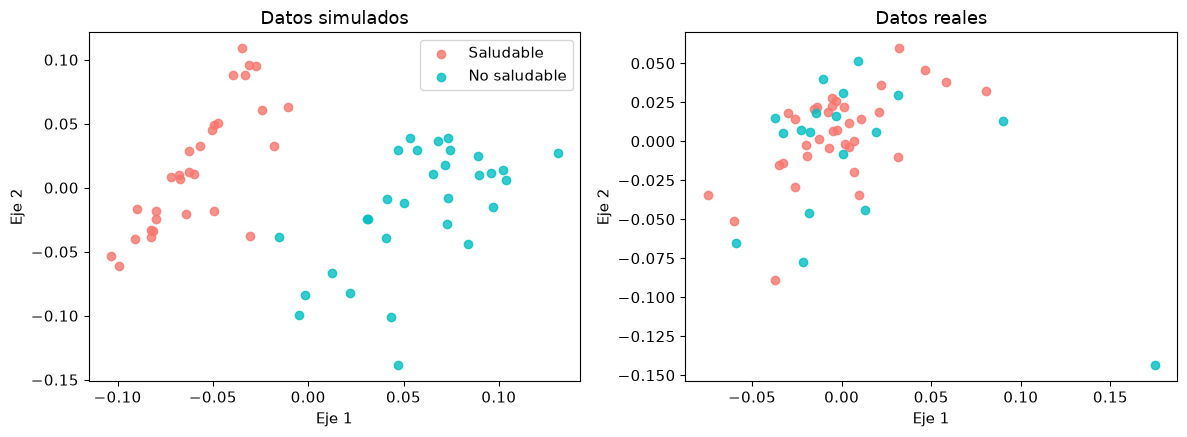

In [11]:
# Un panel por caso: las dos primeras coordenadas principales de cada muestra, coloreadas por grupo
fig, paneles = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (caso, matriz, grupo) in zip(paneles, [("Datos simulados", D_sim, etiquetas_sim), ("Datos reales", D, etiquetas)]):
    coords = pcoa(matriz)                                # columna 0 = eje 1, columna 1 = eje 2
    for g in GRUPOS:
        ax.scatter(coords[grupo == g, 0], coords[grupo == g, 1], color=COLORES[g], label=g, alpha=0.8)
    ax.set_xlabel("Eje 1"); ax.set_ylabel("Eje 2"); ax.set_title(caso)
paneles[0].legend()
fig.tight_layout()                                       # acomoda los paneles para que los rótulos no se monten
plt.show()

**Caso ideal:** dos nubes separadas y de tamaño parecido. El grupo explica cerca del 28 % de la variación, el PERMANOVA es significativo y PERMDISP no: los grupos difieren en su **composición promedio**, no en cuánto varían.

**Caso real:** las nubes se superponen. El grupo explica solo un 2 % y el PERMANOVA no es significativo, pero PERMDISP sí ($p \approx 0.005$): las plantas no saludables **son más heterogéneas en composición**, igual que lo eran en Shannon. Ese es el resultado más sólido de los datos reales.

### Para llevar: ¿qué prueba uso?

| Pregunta | Supuestos | Prueba |
|---|---|---|
| ¿Difieren las medias de un índice? | Normalidad y varianzas iguales | t de Student |
| ¿Difieren las medias de un índice? | Normalidad; varianzas distintas o en duda | t de Welch |
| ¿Un grupo tiende a tener valores mayores? | Ninguno sobre la distribución | Mann-Whitney |
| ¿Difiere la composición completa? | Dispersiones parecidas | PERMANOVA |
| ¿Difiere la variabilidad de la composición? | — | PERMDISP |

La prueba se elige **antes** de ver los valores p, y se reporta siempre el tamaño del efecto (diferencia de medias, $R^2$) junto con el valor p.

### ✏️ Ejercicio 3: ¿Cuántas permutaciones?

⏱️ *4 min*

Repite el PERMANOVA de los datos reales con solo **99 permutaciones** y tres semillas distintas: `permanova(D, etiquetas, n_perm=99, semilla=1)[2]`, y lo mismo con `semilla=2` y `semilla=3`. ¿Qué observas? ¿Por qué se usan al menos 999?

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

Con 99 permutaciones el valor p solo puede tomar valores en múltiplos de 0.01 y cambia de una semilla a otra (0.29, 0.28, 0.26). Con 999 la variación es de milésimas. Un valor p por permutaciones es una estimación: por eso se reporta siempre el número de permutaciones.

```python
for s in (1, 2, 3):
    # [2] es el tercer resultado de la función: el valor p
    print("99 permutaciones, semilla", s, "-> p =", round(permanova(D, etiquetas, n_perm=99, semilla=s)[2], 3))
```

</details>

> **🔑 Puntos clave**
> - Para comparar comunidades completas se trabaja con distancias entre muestras, como la de Bray-Curtis.
> - El PERMANOVA obtiene su valor p barajando etiquetas; su R² dice cuánta variación explica el grupo.
> - El PERMANOVA también reacciona a diferencias de dispersión: se acompaña con PERMDISP y con una ordenación.
> - Cuando las pruebas no coinciden, hay que averiguar qué supuesto falló.

---
## Para profundizar

Este taller rápido es el resumen de un [taller completo](https://colab.research.google.com/github/CamilaSilva1995/Tesis_Maestria/blob/main/Taller_Practico/Taller_Practico_Analisis_estadistico_de_Datos_Metagenomicos.ipynb) de unas tres horas, con los mismos datos. Allí encontrarás lo que aquí quedó fuera:

- La prueba de **Wilcoxon de rangos con signo**, para datos pareados.
- La comparación de **un género de interés** entre grupos (*Fusarium* en los datos reales) y el problema de las **comparaciones múltiples**.
- La construcción del pseudo-F y del valor p del PERMANOVA **paso a paso**.
- Cómo **redactar** un resultado, y más ejercicios.

---
## Referencias

**Lecciones de The Carpentries (conocimientos previos)**

- Data Carpentry. (s. f.). *Análisis y visualización de datos usando Python*. https://datacarpentry.github.io/python-ecology-lesson-es/
- Data Carpentry. (s. f.). *Data Analysis and Visualization in Python for Ecologists*. https://datacarpentry.github.io/python-ecology-lesson/
- Software Carpentry. (s. f.). *Plotting and Programming in Python*. https://swcarpentry.github.io/python-novice-gapminder/
- The Carpentries Lab. (s. f.). *Data Processing and Visualization for Metagenomics*. https://carpentries-lab.github.io/metagenomics-analysis/
- Zirión-Martínez, C., Garfias-Gallegos, D., Arellano-Fernandez, T. V., Espinosa-Jaime, A., Bustos-Díaz, E. D., Lovaco-Flores, J. A., Tejero-Gómez, L. G., Avelar-Rivas, J. A., & Sélem-Mojica, N. (2024). A Data Carpentry-style metagenomics workshop. *Journal of Open Source Education*, 7(72), 209. https://doi.org/10.21105/jose.00209

**Métodos estadísticos**

- Anderson, M. J. (2001). A new method for non-parametric multivariate analysis of variance. *Austral Ecology*, 26(1), 32–46. https://doi.org/10.1111/j.1442-9993.2001.01070.x
- Anderson, M. J. (2006). Distance-based tests for homogeneity of multivariate dispersions. *Biometrics*, 62(1), 245–253. https://doi.org/10.1111/j.1541-0420.2005.00440.x
- Bray, J. R., & Curtis, J. T. (1957). An ordination of the upland forest communities of southern Wisconsin. *Ecological Monographs*, 27(4), 325–349. https://doi.org/10.2307/1942268
- Mann, H. B., & Whitney, D. R. (1947). On a test of whether one of two random variables is stochastically larger than the other. *The Annals of Mathematical Statistics*, 18(1), 50–60. https://doi.org/10.1214/aoms/1177730491
- Shannon, C. E. (1948). A mathematical theory of communication. *The Bell System Technical Journal*, 27(3), 379–423. https://doi.org/10.1002/j.1538-7305.1948.tb01338.x
- Shapiro, S. S., & Wilk, M. B. (1965). An analysis of variance test for normality (complete samples). *Biometrika*, 52(3-4), 591–611. https://doi.org/10.1093/biomet/52.3-4.591
- Welch, B. L. (1947). The generalization of "Student's" problem when several different population variances are involved. *Biometrika*, 34(1-2), 28–35. https://doi.org/10.1093/biomet/34.1-2.28

**Datos metagenómicos y software**

- Gloor, G. B., Macklaim, J. M., Pawlowsky-Glahn, V., & Egozcue, J. J. (2017). Microbiome datasets are compositional: and this is not optional. *Frontiers in Microbiology*, 8, 2224. https://doi.org/10.3389/fmicb.2017.02224
- Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362. https://doi.org/10.1038/s41586-020-2649-2
- McMurdie, P. J., & Holmes, S. (2013). phyloseq: an R package for reproducible interactive analysis and graphics of microbiome census data. *PLoS ONE*, 8(4), e61217. https://doi.org/10.1371/journal.pone.0061217
- Virtanen, P., et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. https://doi.org/10.1038/s41592-019-0686-2
- Wood, D. E., & Salzberg, S. L. (2014). Kraken: ultrafast metagenomic sequence classification using exact alignments. *Genome Biology*, 15, R46. https://doi.org/10.1186/gb-2014-15-3-r46

**Fuente de los datos y del análisis**

- Silva Gómez, P. C. (2026). *Análisis estadístico de la diversidad microbiana a distintos niveles taxonómicos en el microbioma rizosférico de plantas de fresa saludables y no saludables*. Tesis de Maestría en Ciencias Matemáticas, Posgrado Conjunto UMSNH-UNAM. Código y datos: https://github.com/CamilaSilva1995/Tesis_Maestria. Datos metagenómicos facilitados por Solena Ag.
- Solena Ag. (2023). [Metagenomas *shotgun* de la rizósfera de plantas de fresa saludables y no saludables] [Conjunto de datos no publicado]. https://www.solena.ag

---
*Datos facilitados por Solena Ag. Código y datos en [GitHub](https://github.com/CamilaSilva1995/Tesis_Maestria/tree/main/Taller_Practico).*